BGA Classification

In [2]:
# Required Moduls
import numpy as np
import altair as alt
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import umap.umap_ as umap
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

Simple example data

In [4]:
data_train = pd.DataFrame({
    'rs1': ['AA', 'AG', 'AA', 'GG', 'AG'],
    'rs2': ['CC', 'CT', 'CC', 'TT', 'CT'],
    'target': [0, 1, 0, 1, 0]
})

data_test = pd.DataFrame({
    'rs1': ['AG', 'AG', 'AA', 'GG', 'AG'],
    'rs2': ['CT', 'CT', 'CC', 'TT', 'CT'],
    'target': [1, 1, 0, 1, 0]
})

# Target: True Class
X_train = data_train[['rs1', 'rs2']]
y_train = data_train['target']
X_test = data_test[['rs1', 'rs2']]
y_test = data_test['target']

Optional: Upload training data

In [6]:
filepath_train = r'D:\BGA-Classification\data_train.xlsx' #insert filepath

train_data = pd.read_excel(filepath_train)
X_train = train_data.drop(train_data.columns[0], axis=1)
y_train = train_data.iloc[:, 0]

Optional: Upload testing data

In [10]:
filepath_test = r'D:\BGA-Classification\data_test.xlsx' #insert filepath

test_data = pd.read_excel(filepath_test)
X_test = test_data.drop(test_data.columns[0], axis=1)
y_test = test_data.iloc[:, 0]

ROC AUC values

ROC AUC Score: 0.83


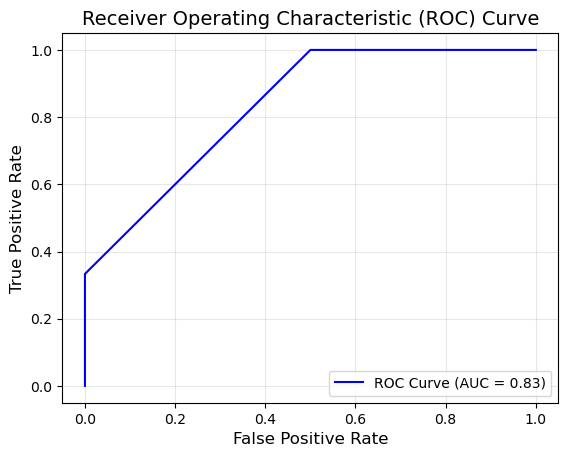

In [14]:
encoder = OneHotEncoder()
X_train_encoded = encoder.fit_transform(X_train).toarray()
X_test_encoded = encoder.transform(X_test).toarray()

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# UMAP with 2 dimensions
#n_components = 2
#reducer = umap.UMAP(n_components=n_components, random_state=42)
#X_train_umap = reducer.fit_transform(X_train_scaled)
#X_test_umap = reducer.transform(X_test_scaled)

# Create and train model
model = RandomForestClassifier()
model.fit(X_train_encoded, y_train)

# Determine ROC AUC
y_pred_proba = model.predict_proba(X_test_encoded)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.2f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot der ROC-Kurve ####################################################
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.title("Receiver Operating Characteristic (ROC) Curve", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

Confusion matrix

In [17]:
y_pred = model.predict(X_test_encoded)
cm = confusion_matrix(y_test, y_pred)
pd.DataFrame(cm)

,0,1
0,2,0
1,2,1


SHAP values

In [20]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_encoded)  # Liste mit SHAP-Werten pro Sample##################################

feature_names = encoder.get_feature_names_out()
n_classes = shap_values.shape[2]  # Anzahl der Klassen ###################
class_names = model.classes_
n_features = len(feature_names)

# mean shap value over all samples
mean_shap_values = np.zeros((n_features, n_classes))

for sample_shap_values in shap_values:
    mean_shap_values += np.abs(sample_shap_values)

mean_shap_values /= len(shap_values)

# DataFrame for each class
shap_df_list = []
for class_index in range(n_classes):
    class_shap_df = pd.DataFrame({
        "Feature": feature_names,
        "MeanSHAP": mean_shap_values[:, class_index],
        "Class": f"Class {class_names[class_index]}"
    })
    shap_df_list.append(class_shap_df)

shap_all_classes_df = pd.concat(shap_df_list, ignore_index=True)

# Altair Plot
shap_chart = alt.Chart(shap_all_classes_df).mark_bar().encode(
    x=alt.X("MeanSHAP:Q", title="Mean SHAP Value"),
    y=alt.Y("Feature:N", sort="-x", title="Feature"),
    color=alt.Color("Class:N", title="Class"),
    tooltip=["Class", "Feature", "MeanSHAP"]
).properties(
    title="SHAP values for features by class",
    width=800,
    height=600
)

shap_chart

alt.Chart(...)